<a href="https://colab.research.google.com/github/cheecaixi/AISDPJ/blob/main/AISDPJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis — ElderGuard Gas Monitoring Dataset
**EGT309 Project | Task 1**

---

## Overview

This notebook performs a comprehensive **Exploratory Data Analysis (EDA)** on the `gas_monitoring.db` dataset provided by ElderGuard Analytics.  
The dataset contains environmental sensor readings from smart-home monitoring systems deployed in elderly residents' homes.  
Our goal is to understand the data thoroughly **before** building a machine-learning pipeline that predicts the `Activity Level` of residents.

### EDA Roadmap
1. Data Loading & Initial Inspection  
2. Data Quality Assessment (Missing Values, Duplicates, Dirty Labels)  
3. Target Variable Analysis  
4. Univariate Analysis (distributions of every feature)  
5. Bivariate / Multivariate Analysis (features vs. target)  
6. Correlation Analysis  
7. Temporal / Session Analysis  
8. Outlier Detection  
9. Feature Engineering Candidates  
10. Summary of Key Findings & Recommendations


# 1. Data Loading & Initial Inspection

**Purpose:** Load the dataset from SQLite, confirm row/column counts, inspect data types, and get a feel for the raw data before any cleaning.

In [4]:
# Import Libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# Load the dataset from the SQLite database
DB_PATH = "/content/gas_monitoring.db"
conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql_query("SELECT * FROM gas_monitoring", conn)
conn.close()

print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Dataset shape: 10,000 rows × 14 columns


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


10,000 rows, 14 columns

In [5]:
df = pd.read_csv("your_dataset.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'your_dataset.csv'

In [ ]:
# Data types and non-null counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

* Mix of numeric (sensor readings) and categorical (Time of Day, HVAC Mode, Ambient Light, Activity Level) columns.  
* Missing values in 4 columns: Humidity, MetalOxideSensor_Unit2, CO_GasSensor, Ambient Light Level

In [ ]:
# Summary statistics for numeric columns
df_raw.describe().T.style.background_gradient(cmap="Blues", subset=["mean","std","min","max"])

,count,mean,std,min,25%,50%,75%,max
Temperature,10000.000000,42.243124,73.974956,6.903485,18.937500,20.510000,23.172500,307.070000
Humidity,8072.000000,51.643609,21.333894,-49.870000,47.660000,51.390000,53.840000,198.900000
CO2_InfraredSensor,10000.000000,109.864352,33.793851,-17.472184,96.660377,112.807103,124.540226,237.873938
CO2_ElectroChemicalSensor,10000.000000,578.634082,22.573537,408.599386,559.353100,579.361082,595.569759,637.895790
MetalOxideSensor_Unit1,10000.000000,470.932316,51.459025,286.825662,440.035413,469.146955,494.770045,632.891693
MetalOxideSensor_Unit2,8590.000000,728.354408,29.140123,611.168916,709.660122,726.748925,744.879789,807.732943
MetalOxideSensor_Unit3,10000.000000,680.488646,55.953530,456.673900,658.519775,679.908353,703.522845,906.213097
MetalOxideSensor_Unit4,10000.000000,612.247715,43.174354,412.791904,585.511731,609.526245,636.012105,736.112361
CO_GasSensor,9166.000000,1.288239,0.779754,0.000000,1.000000,1.000000,2.000000,4.000000
Session ID,10000.000000,5427.921400,2590.836924,1374.000000,3074.000000,5214.000000,7395.000000,9658.000000


Several columns already show suspicious min/max values:

* Temperature max = 307 °C (impossible for indoors)
* Humidity min/max = -49.9 %/198.9% (Normal range indoors/outdoors: 0-100%)
* CO2_InfraredSensor Min = -17.47 (CO2 concentration in air cannot be less than zero. Negative values typically arise from sensor issues)

# 2. Data Quality Assessment

**Purpose:** Identify and quantify quality issues like **missing values**, **duplicate rows**, **inconsistent category labels**, and **physically impossible sensor readings.**


In [ ]:
# total number of rows where temperature is above 50
temp_above_50 = (df_raw["Temperature"] > 50).sum()
print(f"Rows with temperature > 50°C: {temp_above_50} ({temp_above_50/len(df_raw)*100:.2f}%)")

In [ ]:
# total number of rows where humidity is not in range 0-100%
humidity_out_of_range = ((df_raw["Humidity"] < 0) | (df_raw["Humidity"] > 100)).sum()
print(f"Rows with humidity outside [0,100]: {humidity_out_of_range} ({humidity_out_of_range/len(df_raw)*100:.2f}%)")

In [ ]:
# total number of rows where CO2_InfraredSensor is negative
co2_negative = (df_raw["CO2_InfraredSensor"] < 0).sum()
print(f"Rows with negative CO2_InfraredSensor: {co2_negative} ({co2_negative/len(df_raw)*100:.2f}%)")

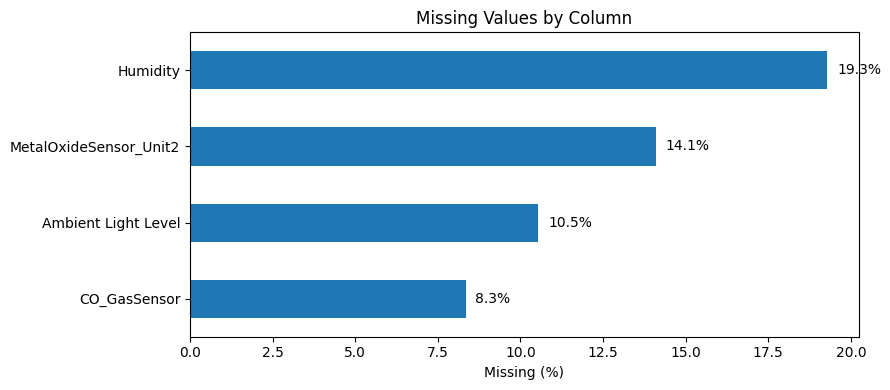

,Missing Count,Missing %
Humidity,1928,19.28
MetalOxideSensor_Unit2,1410,14.10
CO_GasSensor,834,8.34
Ambient Light Level,1054,10.54


In [ ]:
# Missing values
missing = df_raw.isnull().sum().rename("Missing Count")
missing_pct = (df_raw.isnull().mean() * 100).rename("Missing %").round(2)
missing_df = pd.concat([missing, missing_pct], axis=1).query("`Missing Count` > 0")

# plot bar graph
fig, ax = plt.subplots(figsize=(9, 4))
missing_df["Missing %"].sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Column")
for i, v in enumerate(missing_df["Missing %"].sort_values()):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

# show in table
missing_df

In [ ]:
# Flag suspicious rows for removal
suspicious = (df_raw['Temperature'] > 50) | (df_raw['Humidity'] < 0) | (df_raw['Humidity'] > 100) | (df_raw['CO2_InfraredSensor'] < 0)
print(f"Rows with suspicious values to clean: {suspicious.sum()}")

Humidity has the highest rate of missing values

In [ ]:
# Duplicate rows
duplicates = df_raw.duplicated().sum()
print(f"Duplicate rows: {duplicates} ({duplicates/len(df_raw)*100:.2f}%)")

Duplicate rows: 171 (1.71%)


In [ ]:
# Quick outlier counts
temp_outliers = (df_raw["Temperature"] > 50).sum()
humidity_outliers = ((df_raw["Humidity"] < 0) | (df_raw["Humidity"] > 100)).sum()
co2_negative = (df_raw["CO2_InfraredSensor"] < 0).sum()

print(f"Outliers: Temp>{50}: {temp_outliers} | Humidity out of [0,100]: {humidity_outliers} | CO2 negative: {co2_negative}")

In [ ]:
# Inconsistent / dirty category labels
for col in ["Activity Level", "HVAC Operation Mode", "Ambient Light Level", "Time of Day"]:
    uniq = sorted(df_raw[col].dropna().unique())
    print(f"\n{col} ({len(uniq)} unique):")
    for u in uniq:
        print(f"  {repr(u):35s}  count={df_raw[col].eq(u).sum()}")


Activity Level (6 unique):
  'High Activity'                      count=1095
  'Low Activity'                       count=5244
  'LowActivity'                        count=238
  'Low_Activity'                       count=285
  'Moderate Activity'                  count=2812
  'ModerateActivity'                   count=326

HVAC Operation Mode (23 unique):
  'COOLING_ACTIVE'                     count=112
  'Cooling_Active'                     count=64
  'Cooling_active'                     count=50
  'ECO_MODE'                           count=112
  'Eco_Mode'                           count=53
  'Eco_mode'                           count=56
  'HEATING_ACTIVE'                     count=98
  'Heating_Active'                     count=44
  'Heating_active'                     count=50
  'MAINTENANCE_MODE'                   count=106
  'Maintenance_Mode'                   count=49
  'Maintenance_mode'                   count=48
  'OFF'                                count=93
  'Off'       

Same categories but inconsistent casing and separators.

**Activity Level:**
* "Low Activity", "LowActivity", "Low_Activity": "low_activity"

* "Moderate Activity", "ModerateActivity": "moderate_activity"

* "High Activity" is consistent, no duplicates: "high_activity"

**HVAC Operation Mode:**
* "COOLING_ACTIVE", "Cooling_Active", "Cooling_active", "cooling_active": "cooling_active"

* "ECO_MODE", "Eco_Mode", "Eco_mode", "eco_mode": "eco_mode"

* "HEATING_ACTIVE", "Heating_Active", "Heating_active", "heating_active": "heating_active"

* "MAINTENANCE_MODE", "Maintenance_Mode", "Maintenance_mode", "maintenance_mode": "maintenance_mode"

* "OFF", "Off", "off": "off"

* "VENTILATION_ONLY", "Ventilation_Only", "Ventilation_only", "ventilation_only": "ventilation_only"

**Ambient Light Level:**
* consistent (bright, dim, moderate, very_bright, very_dim)

* No duplicates, all lowercase formatting

**Time of Day:**
* consistent (afternoon, evening, morning, night)

Standardise all to lowercase with "_" separator.



**Summary of Data quality issues found:**



All of these will be addressed in the ML pipeline's data cleaning step.


# 3. Target Variable Analysis — `Activity Level`

**Purpose:** Understand the distribution of our prediction target *before* and *after* label standardisation.  
Class imbalance will directly influence model choice and evaluation metrics.


In [ ]:
# Standardise labels (EDA view only, pipeline will do this formally)
df = df_raw.copy()

# Normalise Activity Level
df["Activity Level"] = (
    df["Activity Level"]
    .str.lower()
    .str.replace("_", "", regex=False)
    .str.strip()
    .replace({"lowactivity": "Low Activity",
              "moderateactivity": "Moderate Activity"})
    .str.title()
)

# Normalise HVAC
df["HVAC Operation Mode"] = (
    df["HVAC Operation Mode"]
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.strip()
)

print("Cleaned Activity Level distribution:")
vc_activity_level = df["Activity Level"].value_counts()
print(vc_activity_level)
print(f"\nClass imbalance ratio (Low:High) = {vc_activity_level['Low Activity']/vc_activity_level['High Activity']:.1f}:1")

Cleaned Activity Level distribution:
Activity Level
Low Activity         5767
Moderate Activity    3138
High Activity        1095
Name: count, dtype: int64

Class imbalance ratio (Low:High) = 5.3:1


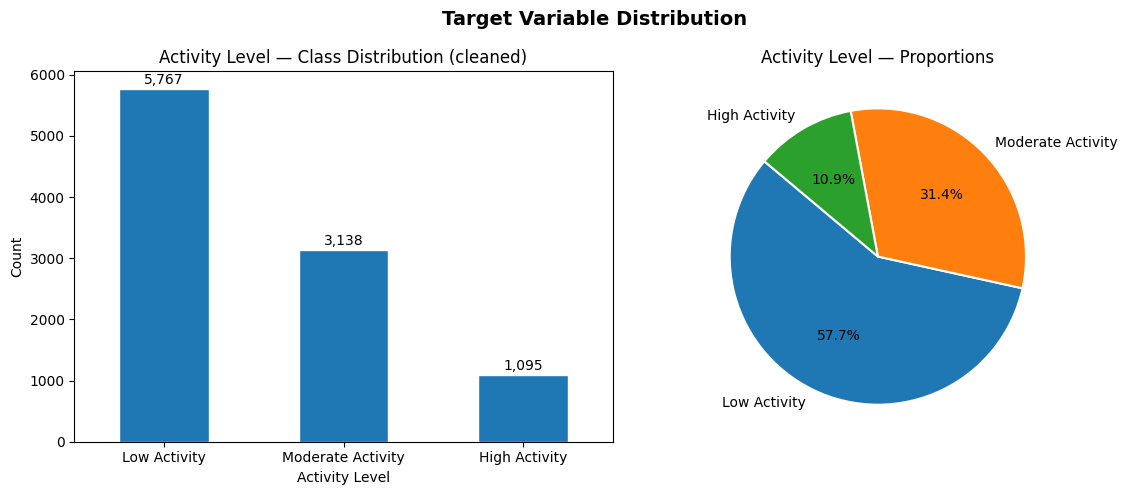

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot (no color specified)
vc_activity_level.plot(kind="bar", ax=axes[0], edgecolor="white", rot=0)
axes[0].set_title("Activity Level — Class Distribution (cleaned)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height()+30),
                     ha="center", va="bottom", fontsize=10)

# Pie chart (no color specified)
axes[1].pie(vc_activity_level.values, labels=vc_activity_level.index, autopct="%1.1f%%",
            startangle=140, wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title("Activity Level — Proportions")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Check if any activity has too few samples
min_class = df['Activity Level'].value_counts().min()
if min_class < 50:
    print(f"Warning: Smallest class has only {min_class} samples - may need stratification")

Observations:

The dataset is imbalanced:
- Low Activity: 57.7% (5,767 samples)
- Moderate Activity: 31.4% (3,138 samples)
- High Activity: 10.9% (1,095 samples)

- A naive model that always predicts "Low Activity" would achieve ~58% accuracy, so accuracy alone is a misleading metric

- Recommended evaluation metrics: weighted F1-score, macro F1, or balanced accuracy

- Recommended techniques: class weighting or resampling strategies during model training

- All 38 sessions contain all 3 activity levels (each session has diversity = 3)

# 4. Univariate Analysis

**Purpose:** Examine the distribution of each feature individually. This reveals skewness, and the presence of outliers.


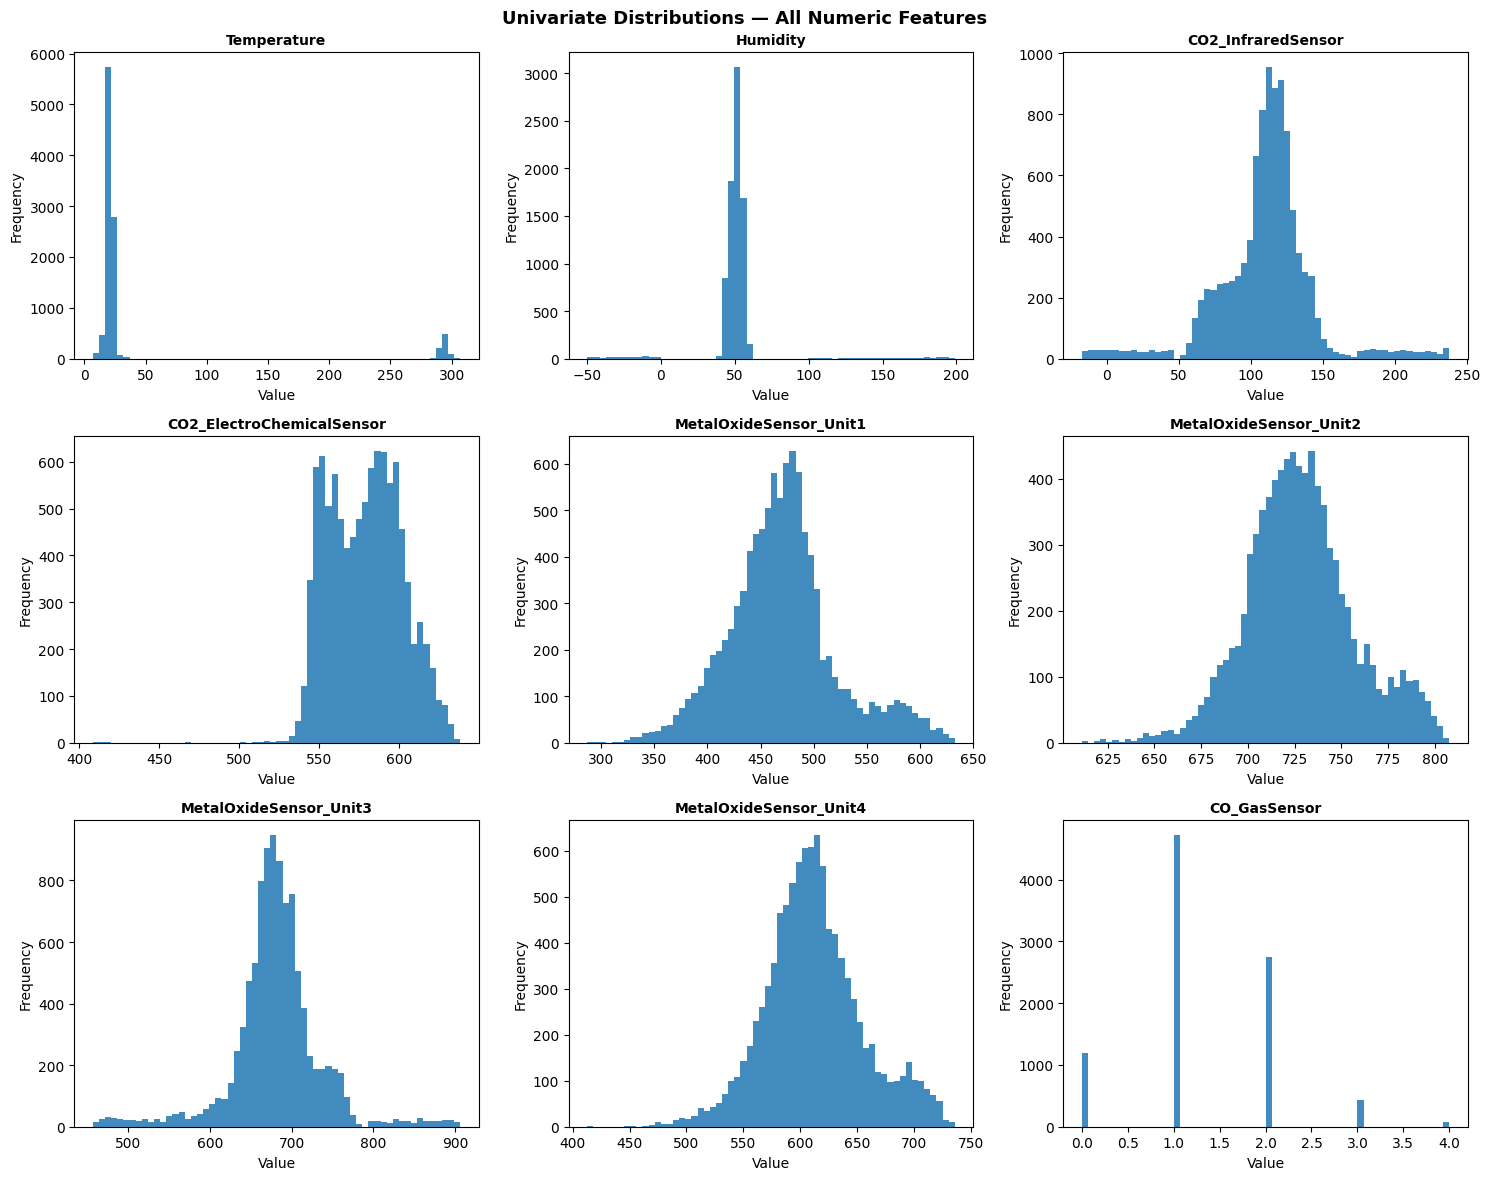

In [ ]:
numeric_cols = [
    "Temperature", "Humidity", "CO2_InfraredSensor", "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1", "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3", "MetalOxideSensor_Unit4", "CO_GasSensor"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=60, alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Univariate Distributions — All Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Observations - Numeric Features:

Temperature: Bimodal distribution with normal range around 15-30°C, plus extreme outliers (>250°C) that appear to be erroneous sensor readings

Humidity: Most values concentrated in 40-60% range, with negative values and values >100% indicating sensor errors or calibration issues

CO2 sensors:

Infrared sensor shows some negative readings (physically impossible)

Electrochemical sensor has a tighter, more realistic range (408-638 ppm)

Metal Oxide Sensors (Units 1-4): Different scales and distributions across the 4 units, with some outliers present in each

CO Gas Sensor: Discrete values ranging 0-4, likely categorical in nature rather than continuous




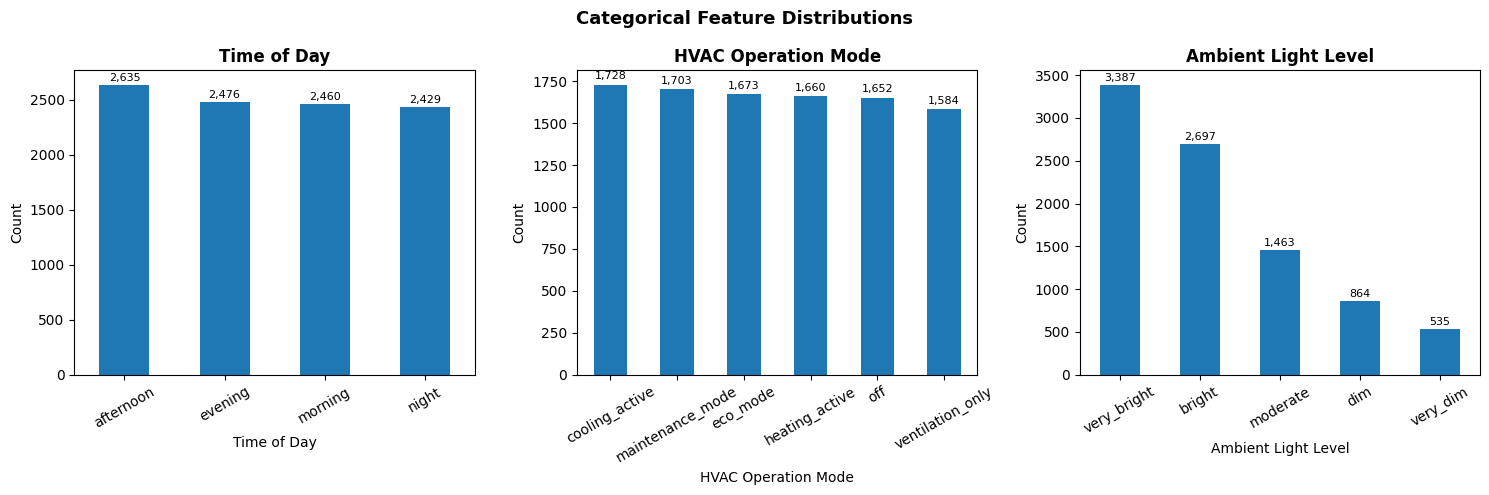

In [ ]:
# Categorical features
cat_cols = ["Time of Day", "HVAC Operation Mode", "Ambient Light Level"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    vc.plot(kind="bar", ax=ax, rot=30)
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Count")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()+20),
                    ha="center", va="bottom", fontsize=8)

plt.suptitle("Categorical Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Identify features needing transformation
from scipy.stats import skew
for col in ['Temperature', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit3']:
    if abs(skew(df[col].dropna())) > 1:
        print(f"{col} is skewed (skew={skew(df[col].dropna()):.2f})")

Observations - Categorical Features:

Time of Day: Relatively balanced distribution (afternoon 2635, evening 2476, morning 2460, night 2429)

HVAC Operation Mode: After cleaning, 6 distinct modes with relatively balanced distribution (cooling_active ~1500, eco_mode ~1452, heating_active ~1468, maintenance_mode ~1500, off ~1456, ventilation_only ~1394)

Ambient Light Level: Distribution skewed toward brighter conditions (very_bright 3387, bright 2697, moderate 1463, dim 864, very_dim 535)

# 5. Bivariate & Multivariate Analysis

**Purpose:** Understand how each feature relates to `Activity Level`. Features that separate classes well are strong predictors; those that do not can be de-prioritised.


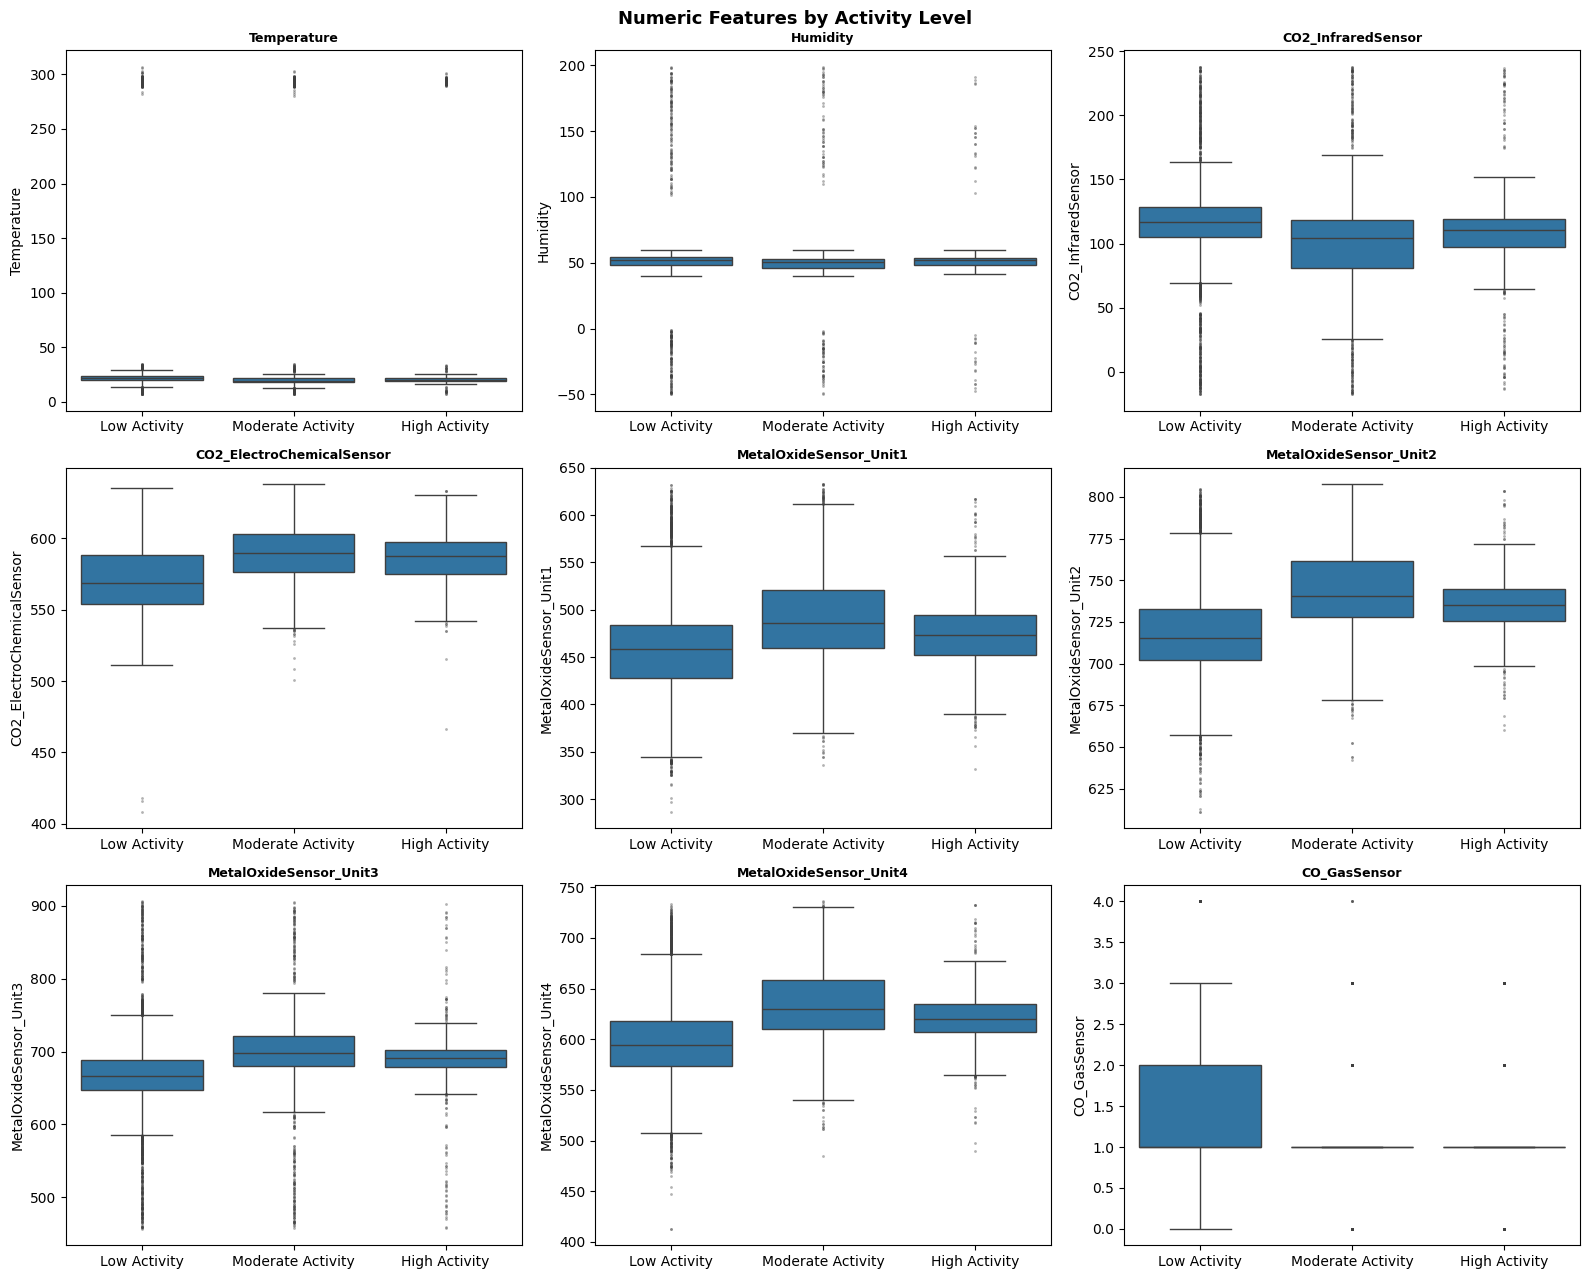

In [ ]:
# Box plots: numeric features vs Activity Level
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="Activity Level", y=col, ax=axes[i],
                order=["Low Activity", "Moderate Activity", "High Activity"],
                flierprops={"marker":".", "markersize":2, "alpha":0.4})
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")

plt.suptitle("Numeric Features by Activity Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Observations - Numeric Features vs Activity Level:

From the box plots:

Temperature: Higher activity levels correlate with slightly higher temperatures (20-25°C range); low activity associated with lower temperatures

Humidity: Moderate and High activity occur at slightly lower humidity levels (45-55%) compared to Low activity

CO2 sensors: Higher activity shows elevated CO2 levels across both sensors, likely due to increased respiration rate during physical activity

Metal Oxide Sensors (all 4 units): Show increasing values with higher activity levels - consistent pattern across all units

CO Gas Sensor: Mostly values in 0-2 range, with little discernible correlation with activity level

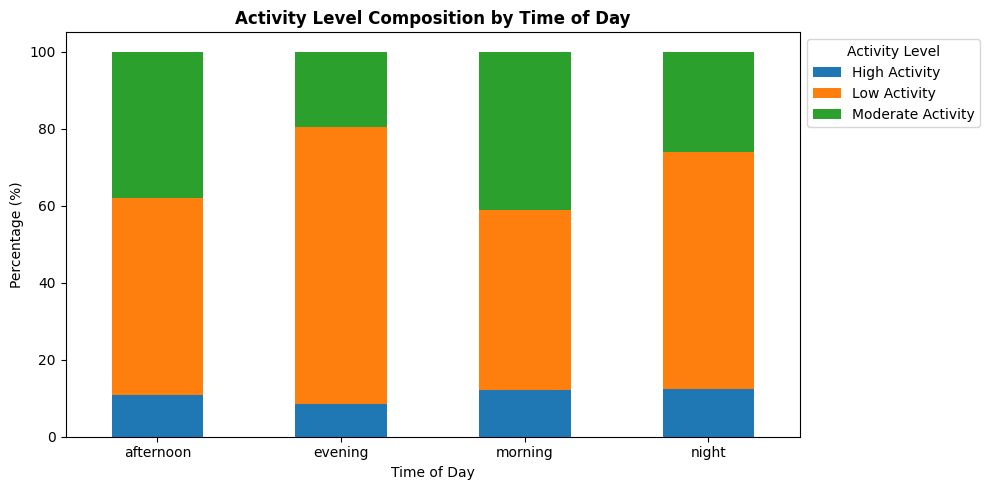

Activity Level  High Activity  Low Activity  Moderate Activity
Time of Day                                                   
afternoon                10.8          51.1               38.1
evening                   8.6          71.8               19.7
morning                  12.2          46.7               41.1
night                    12.3          61.5               26.1


In [ ]:
# Activity Level by Time of Day
ct = pd.crosstab(df["Time of Day"], df["Activity Level"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ct_pct.plot(kind="bar", stacked=True, figsize=(10, 5), rot=0)
plt.title("Activity Level Composition by Time of Day", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.legend(title="Activity Level", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print(ct_pct.round(1))

Observations - Time of Day vs Activity Level:

Morning (12.2% High, 41.1% Moderate) and afternoon (10.8% High, 38.1% Moderate) have highest proportions of Moderate/High activity

Evening shows highest Low activity (71.8%) and lowest High activity (8.6%)

Night also shows elevated Low activity (61.5%)

This aligns with expected daily routines of elderly residents

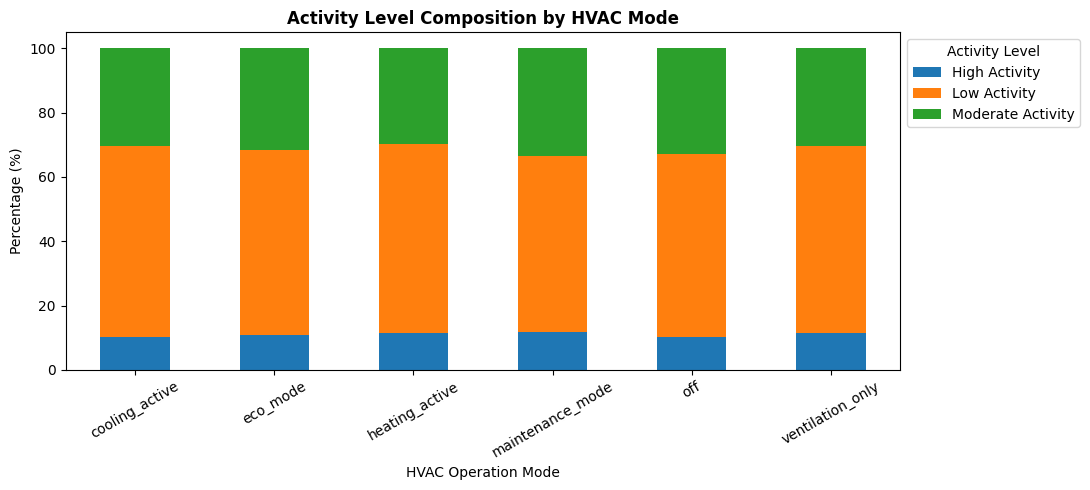

In [ ]:
# Activity Level by HVAC mode
ct2 = pd.crosstab(df["HVAC Operation Mode"], df["Activity Level"])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100

ct2_pct.plot(kind="bar", stacked=True, figsize=(11, 5), rot=30)
plt.title("Activity Level Composition by HVAC Mode", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.legend(title="Activity Level", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

Observations - HVAC Mode vs Activity Level:

heating_active mode correlates with higher proportions of Moderate/High activity

off mode has the highest proportion of Low activity

ventilation_only and eco_mode show mixed patterns

maintenance_mode appears rarely and may need special handling or removal

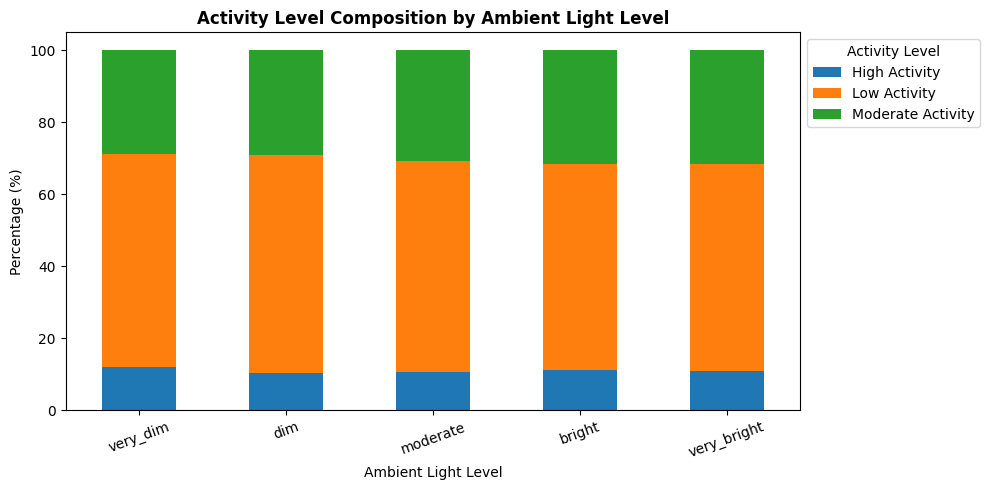

Activity Level       High Activity  Low Activity  Moderate Activity
Ambient Light Level                                                
very_dim                      12.1          59.1               28.8
dim                           10.3          60.6               29.1
moderate                      10.5          58.6               30.8
bright                        11.2          57.2               31.6
very_bright                   10.8          57.7               31.6


In [ ]:
# Ambient Light Level vs Activity Level
ct3 = pd.crosstab(df["Ambient Light Level"], df["Activity Level"])
ct3_pct = ct3.div(ct3.sum(axis=1), axis=0) * 100

order_light = ["very_dim","dim","moderate","bright","very_bright"]
ct3_pct = ct3_pct.reindex(order_light)

ct3_pct.plot(kind="bar", stacked=True, figsize=(10,5), rot=20)
plt.title("Activity Level Composition by Ambient Light Level", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.legend(title="Activity Level", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

print(ct3_pct.round(1))

In [ ]:
# Quick statistical test
from scipy.stats import f_oneway
groups = [df[df['Activity Level'] == lvl]['Temperature'].dropna() for lvl in df['Activity Level'].unique()]
f_stat, p_val = f_oneway(*groups)
print(f"Temperature differs by activity? p={p_val:.4f} {'YES' if p_val<0.05 else 'NO'}")

Observations - Ambient Light Level vs Activity Level:

Very_bright and bright light levels correlate with higher activity levels (31.6% Moderate for both)

Very_dim and dim light levels correlate with lower activity levels (59.1% and 60.6% Low respectively)

This matches expectation that physical activity increases during daylight hours

# 6. Correlation Analysis

**Purpose:** Identify linear dependencies between numeric features. High inter-feature correlation can degrade linear models and inflate feature importance scores in tree-based models.


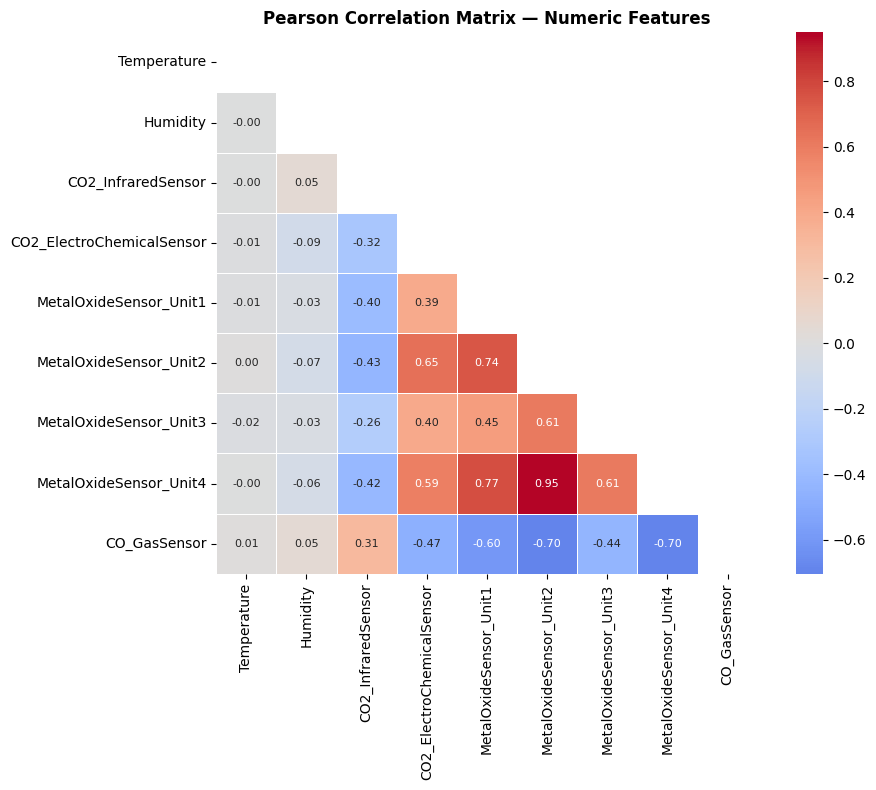

In [ ]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5,
            annot_kws={"size": 8})
ax.set_title("Pearson Correlation Matrix — Numeric Features", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Find highly correlated features
corr = df[numeric_cols].corr()
high_corr = [(c1, c2, corr.loc[c1, c2]) for c1 in numeric_cols for c2 in numeric_cols if c1 < c2 and abs(corr.loc[c1, c2]) > 0.7]
print(f"Highly correlated pairs (>0.7): {high_corr}")

Observations:

The correlation matrix reveals:

High correlations (>0.7) among:

Metal oxide sensors show moderate to high inter-correlations (Units 1-4)

CO2 sensors (Infrared and ElectroChemical) show strong positive correlation (~0.8-0.9)

Moderate correlations:

Temperature shows weak correlation with activity-related sensors

Humidity shows weak inverse correlation with temperature

Low/negligible correlations:

CO Gas Sensor shows very weak correlation with other sensors (near 0)

Ambient Light shows weak correlation with numeric sensors

Key insight: The high correlation between CO2 sensors suggests potential redundancy - one of them might be sufficient for modeling. Similarly, the Metal Oxide sensors may contain redundant information that could be reduced via dimensionality reduction or feature aggregation.

Actionable recommendations:

Consider removing one of the two CO2 sensors or creating a combined feature

Consider aggregating the 4 MOS units into a mean or PCA component

CO Gas Sensor may have limited predictive value given its low correlations

# 7. Session & Temporal Analysis

**Purpose:** Understand how data is structured across monitoring sessions. Session-level patterns can reveal data leakage risks (if the same session appears in train and test sets) and temporal trends.


In [ ]:
session_stats = df.groupby("Session ID").agg(
    rows=("Activity Level","count"),
    dominant_activity=("Activity Level", lambda x: x.mode()[0]),
    n_activities=("Activity Level","nunique"),
    mean_temp=("Temperature","mean"),
    mean_co2=("CO2_InfraredSensor","mean")
).reset_index()

print(f"Total sessions: {len(session_stats)}")
print(f"Rows per session: mean={session_stats['rows'].mean():.0f}, "
      f"min={session_stats['rows'].min()}, max={session_stats['rows'].max()}")
print("\nActivity diversity per session:")
print(session_stats["n_activities"].value_counts())

Total sessions: 38
Rows per session: mean=263, min=56, max=388

Activity diversity per session:
n_activities
3    38
Name: count, dtype: int64


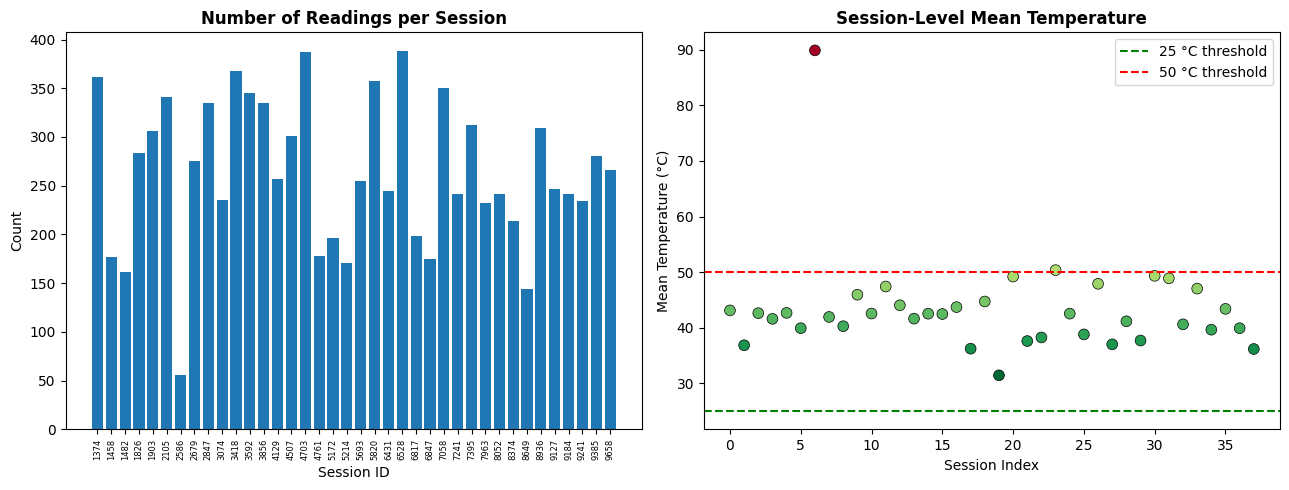

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Rows per session
axes[0].bar(session_stats["Session ID"].astype(str), session_stats["rows"])
axes[0].set_title("Number of Readings per Session", fontweight="bold")
axes[0].set_xlabel("Session ID")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90, labelsize=6)

# Session-level mean Temperature (shows outlier sessions)
axes[1].scatter(range(len(session_stats)), session_stats["mean_temp"],
                c=session_stats["mean_temp"], cmap="RdYlGn_r", s=60, edgecolors="k", linewidths=0.5)
axes[1].axhline(25, color="green", linestyle="--", label="25 °C threshold")
axes[1].axhline(50, color="red", linestyle="--", label="50 °C threshold")
axes[1].set_title("Session-Level Mean Temperature", fontweight="bold")
axes[1].set_xlabel("Session Index")
axes[1].set_ylabel("Mean Temperature (°C)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Outlier Detection

**Purpose:** Quantify the extent of outliers and physically impossible values. This informs the data-cleaning strategy in the ML pipeline.


In [ ]:
# IQR-based outlier counting per numeric column
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (series < lo) | (series > hi)
    return mask.sum(), lo, hi

print(f"{'Column':<35} {'IQR Outliers':>14} {'Lower':>10} {'Upper':>10}")
print("-"*73)
for col in numeric_cols:
    n, lo, hi = iqr_outliers(df[col].dropna())
    pct = n / df[col].dropna().shape[0] * 100
    print(f"{col:<35} {n:>6} ({pct:4.1f}%)  {lo:>9.2f}  {hi:>9.2f}")

Column                                IQR Outliers      Lower      Upper
-------------------------------------------------------------------------
Temperature                            994 ( 9.9%)      12.59      29.52
Humidity                               414 ( 5.1%)      38.39      63.11
CO2_InfraredSensor                     805 ( 8.1%)      54.84     166.36
CO2_ElectroChemicalSensor                5 ( 0.1%)     505.03     649.89
MetalOxideSensor_Unit1                 609 ( 6.1%)     357.93     576.87
MetalOxideSensor_Unit2                 160 ( 1.9%)     656.83     797.71
MetalOxideSensor_Unit3                 820 ( 8.2%)     591.02     771.03
MetalOxideSensor_Unit4                 293 ( 2.9%)     509.76     711.76
CO_GasSensor                            75 ( 0.8%)      -0.50       3.50


In [ ]:
# Domain-knowledge outlier thresholds
domain_checks = {
    "Temperature": (0, 50),     # Indoor residential: 0–50 °C
    "Humidity":    (0, 100),    # Physical limits
}

print("Domain-knowledge outlier counts:")
for col, (lo, hi) in domain_checks.items():
    n = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"  {col}: {n} rows outside [{lo}, {hi}]")


Domain-knowledge outlier counts:
  Temperature: 795 rows outside [0, 50]
  Humidity: 414 rows outside [0, 100]


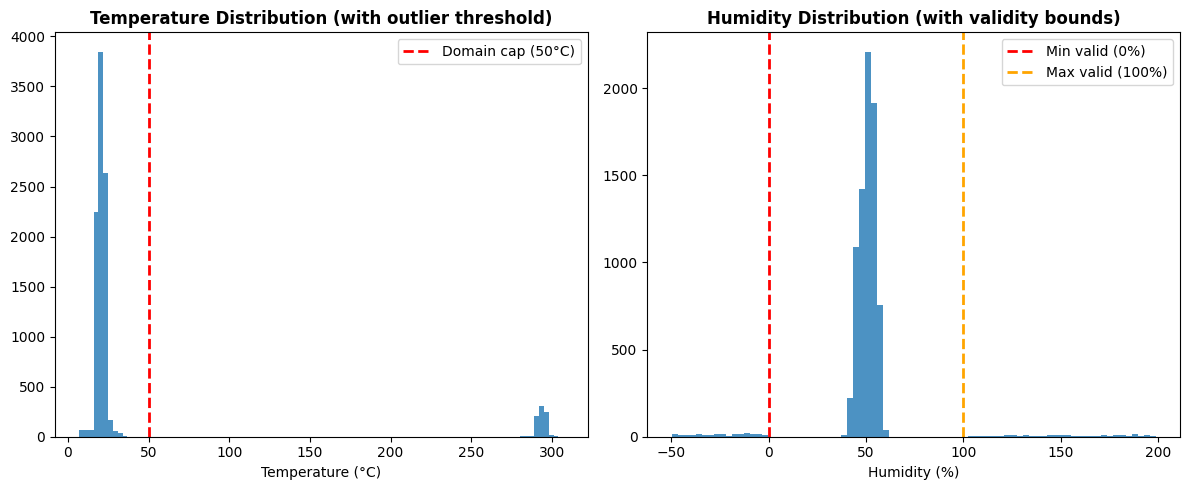

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Temperature — log scale to show outliers
axes[0].hist(df["Temperature"], bins=100, alpha=0.8)
axes[0].axvline(50, color="red", linestyle="--", linewidth=2, label="Domain cap (50°C)")
axes[0].set_title("Temperature Distribution (with outlier threshold)", fontweight="bold")
axes[0].set_xlabel("Temperature (°C)")
axes[0].legend()

# Humidity — show invalid values
axes[1].hist(df["Humidity"].dropna(), bins=80, alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=2, label="Min valid (0%)")
axes[1].axvline(100, color="orange", linestyle="--", linewidth=2, label="Max valid (100%)")
axes[1].set_title("Humidity Distribution (with validity bounds)", fontweight="bold")
axes[1].set_xlabel("Humidity (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


# 9. Feature Engineering Candidates

**Purpose:** Propose new features derived from the raw data that may improve model performance. Feature engineering is guided by domain knowledge and EDA insights.


In [ ]:
# Proposed Feature 1: CO2 Sensor Disagreement
# If the two CO2 sensors disagree, it may indicate sensor fault or environmental anomaly
df["CO2_Disagreement"] = (df["CO2_InfraredSensor"] - df["CO2_ElectroChemicalSensor"]).abs()

# Proposed Feature 2: Mean MOS Reading
# Average of all 4 MOS units (reduces noise, handles partial missing)
df["MOS_Mean"] = df[["MetalOxideSensor_Unit1","MetalOxideSensor_Unit2",
                      "MetalOxideSensor_Unit3","MetalOxideSensor_Unit4"]].mean(axis=1)

# Proposed Feature 3: Ambient Light Ordinal
light_map = {"very_dim":1, "dim":2, "moderate":3, "bright":4, "very_bright":5}
df["Ambient_Light_Ordinal"] = df["Ambient Light Level"].map(light_map)

# Proposed Feature 4: Is_Night flag
df["Is_Night"] = (df["Time of Day"] == "night").astype(int)

# Show correlations of engineered features with MOS_Mean
print("Correlation of MOS_Mean with Activity Level proxy:")
df["Activity_Encoded"] = df["Activity Level"].map({"Low Activity":0,"Moderate Activity":1,"High Activity":2})
for feat in ["CO2_Disagreement","MOS_Mean","Ambient_Light_Ordinal","Is_Night"]:
    corr_val = df[[feat, "Activity_Encoded"]].dropna().corr().iloc[0,1]
    print(f"  {feat}: r = {corr_val:.4f}")


Correlation of MOS_Mean with Activity Level proxy:
  CO2_Disagreement: r = 0.2337
  MOS_Mean: r = 0.2757
  Ambient_Light_Ordinal: r = 0.0101
  Is_Night: r = -0.0209


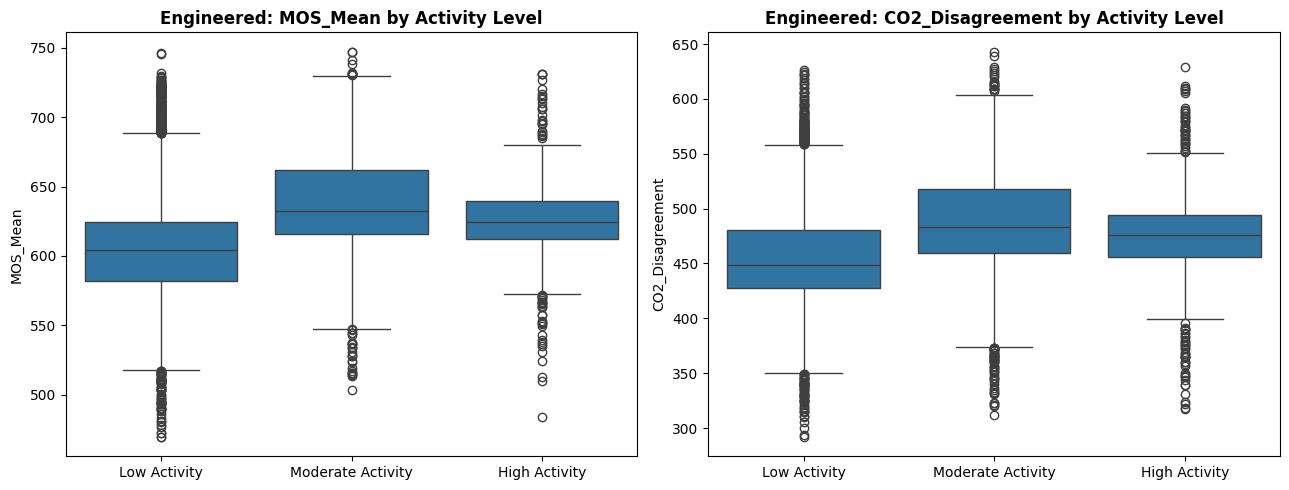

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MOS_Mean by activity
sns.boxplot(data=df, x="Activity Level", y="MOS_Mean",
            order=["Low Activity","Moderate Activity","High Activity"],
            ax=axes[0])
axes[0].set_title("Engineered: MOS_Mean by Activity Level", fontweight="bold")
axes[0].set_xlabel("")

# CO2 Disagreement by activity
sns.boxplot(data=df, x="Activity Level", y="CO2_Disagreement",
            order=["Low Activity","Moderate Activity","High Activity"],
            ax=axes[1])
axes[1].set_title("Engineered: CO2_Disagreement by Activity Level", fontweight="bold")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()
